# *Problema de Poisson 2D*

Sea el dominio $\Omega=[0,1]\times[0,1]$. Tenemos la ecuación de Poisson:

$$\Delta u(x,y)=−2\pi^{2}\sin(\pi x)\sin(\pi y),\quad (x,y)\in\Omega,$$con condiciones de Dirichlet homogéneas en la frontera:$$u(x,y)=0\quad\text{para }(x,y)\in\partial\Omega.$$

La solución exacta es:$$\boxed{\,u(x,y)=\sin(\pi x)\sin(\pi y)\,}$$ En primera instancia podemos comprobar directamente que $\Delta u = u_{xx}+u_{yy} = -2\pi^{2}\sin(\pi x)\sin(\pi y)$ y que la condición de frontera ($u=0$ en $\partial\Omega$) se cumple.

Tareas Obligatorias (Entregables)

1. Derivación Analítica Breve: Verificar algebraicamente que la función propuesta es solución del problema. Escribir las comprobaciones de las segundas derivadas parciales $u_{xx}$ y $u_{yy}$. Verificar la ecuación de Poisson ($\Delta u = f$). Verificar la Condición de Frontera (BC).

2. Método Numérico — Diferencias Finitas (FD): Discretizar el dominio $\Omega$ con una malla uniforme $N\times N$ (sugerido $N=51, 101$). Formulación: Formular el esquema de 5 puntos para $\Delta u$ y armar el sistema lineal $A\mathbf{u}=\mathbf{b}$. Resolución: Resolver con un solver iterativo (Gauss–Seidel o SOR) y con un solver directo para comparación (e.g., usando SciPy). Métricas: Calcular y reportar la norma RMS y la norma $L^\infty$ del error frente a la solución exacta, para al menos dos refinamientos de malla.  Incluir tiempos de ejecución para ambos solvers.

3. PINN (Physics-Informed Neural Network) Arquitectura: Construir una red $u_{\theta}(x,y) \approx u(x,y)$ (denotada $\mathrm{NN}(x,y;\theta)$) que aproxime $u$. Residuo y Pérdida: Usar el residuo $r(x,y)=u_{xx}+u_{yy} + 2\pi^{2}\sin(\pi x)\sin(\pi y)$. Minimizar la pérdida total $\mathcal{L} = \mathcal{L}_{\mathrm{phys}} + \mathcal{L}_{\mathrm{BC}}$, donde $\mathcal{L}_{\mathrm{phys}}=\mathrm{MSE}(r)$ en puntos de colocación interiores y $\mathcal{L}_{\mathrm{BC}}$ es la pérdida en la frontera. Mejoras Obligatorias:Implementar una *trial solution* $u_{\text{trial}}$ que garantice las BC (hard constraints). Normalizar entradas a $[-1,1]$. Entrenar con Adam y afinar con LBFGS. Reporte: Reportar RMS y $L^\infty$ del error usando la misma malla que en FD. Mostrar mapas de residuo y del error absoluto.

4. Comparación y Análisis Visual: Tres gráficos comparativos (Solución Analítica / FD / PINN). Mapas de error absoluto para cada método. Un scatter/heatmap del residuo de la PINN.

Comentario Crítico: Discusión sobre ventajas/desventajas observadas; dónde falla cada método y por qué (resolución, tratamiento BC, arquitectura, sampling).

Requisitos Técnicos y Recomendaciones:
- Diferencias Finitas (FD): Implementar el esquema de 5 puntos (para $A\mathbf{u}=\mathbf{b}$). Para SOR, probar $\omega\in[1.0,1.9]$.
Usar la condición de convergencia: $\lVert u^{k+1}-u^k\rVert_\infty<10^{-8}$ o un máximo de iteraciones.

- PINN Arquitectura Sugerida: $[2, 128, 128, 128, 1]$ con activación $\tanh$. Puntos de Collocation: Usar $8\mathrm{k}–20\mathrm{k}$ puntos. Precisión: Considerar float64 si hay problemas numéricos. Optimizadores: Adam ($lr \approx 1\mathrm{e}{-3}$ con scheduler) seguido de LBFGS ($200–1000$ iteraciones). Trial Solution ($u_{\text{trial}}$): Utilizar la forma $u_{\text{trial}}(x,y) = x(1-x)y(1-y)N(x,y)$ o cualquier otra forma que imponga BC exactas ($u_{\text{trial}}|_{\partial\Omega}=0$). (Adaptar si las entradas están normalizadas a $[-1, 1]$). Métricas Norma RMS: $\sqrt{\frac{1}{M}\sum (u_{\text{num}}-u_{\text{exact}})^2}$.Norma $L^\infty$ (Error Máximo): $\max|u_{\text{num}}-u_{\text{exact}}|$.Mostrar también el máximo absoluto del residuo en la malla.

- Entrega Notebook (o .py) reproducible con celdas ejecutables y figuras embebidas. Un PDF de una página con conclusiones. Añadir comentarios en el código que expliquen parámetros seleccionados.

* Criterios de Evaluación (Sugeridos, %)
* Correctitud analítica y verificación (15%).
* Implementación FD y convergencia / análisis de error (25%).
* Implementación PINN con mejoras exigidas (trial solution, normalización, optimizer strategy) y documentación (30%).
* Comparación, visualización y discusión crítica (20%).
* Limpieza del notebook y reproducibilidad (10%).

---
# *Verificación Analítica de la Solución Exacta de la Ecuación de Poisson*
---

La solución propuesta es:
$$u(x,y)=\sin(\pi x)\sin(\pi y)$$

## 1. Verificación del Laplaciano ($\Delta u$)

Debemos verificar que $\Delta u = u_{xx} + u_{yy} = −2\pi^{2}\sin(\pi x)\sin(\pi y)$.

### 1.1. Cálculo de $u_{xx}$

Calculamos la primera derivada parcial $u_x$:
$$u_x = \frac{\partial u}{\partial x} = \frac{\partial}{\partial x}\left[\sin(\pi x)\sin(\pi y)\right] = \pi \cos(\pi x)\sin(\pi y)$$

Calculamos la segunda derivada parcial $u_{xx}$:
\begin{align*}
u_{xx} &= \frac{\partial}{\partial x}\left[\pi \cos(\pi x)\sin(\pi y)\right] \\
&= \pi \sin(\pi y) \cdot \left[-\pi \sin(\pi x)\right] \\
u_{xx} &= -\pi^2 \sin(\pi x)\sin(\pi y)
\end{align*}

### 1.2. Cálculo de $u_{yy}$

Calculamos la primera derivada parcial $u_y$:
$$u_y = \frac{\partial u}{\partial y} = \frac{\partial}{\partial y}\left[\sin(\pi x)\sin(\pi y)\right] = \pi \sin(\pi x)\cos(\pi y)$$

Calculamos la segunda derivada parcial $u_{yy}$:
\begin{align*}
u_{yy} &= \frac{\partial}{\partial y}\left[\pi \sin(\pi x)\cos(\pi y)\right] \\
&= \pi \sin(\pi x) \cdot \left[-\pi \sin(\pi y)\right] \\
u_{yy} &= -\pi^2 \sin(\pi x)\sin(\pi y)
\end{align*}

### 1.3. Suma del Laplaciano

Sumamos ambas segundas derivadas:
$$\Delta u = u_{xx} + u_{yy} = \left(-\pi^2 \sin(\pi x)\sin(\pi y)\right) + \left(-\pi^2 \sin(\pi x)\sin(\pi y)\right)$$
$$\Delta u = -2\pi^2 \sin(\pi x)\sin(\pi y)$$

**Conclusión Parcial:** La ecuación de Poisson se satisface.

## 2. Verificación de la Condición de Dirichlet ($\mathbf{u=0}$ en $\partial\Omega$)

El dominio es $\Omega=[0,1]\times[0,1]$. La condición requiere que $u(x,y)=0$ en los bordes $x=0$, $x=1$, $y=0$, y $y=1$.

### 2.1. Bordes $x=0$ y $x=1$

* Para $x=0$:
    $$u(0,y) = \sin(\pi \cdot 0)\sin(\pi y) = 0 \cdot \sin(\pi y) = 0$$
* Para $x=1$:
    $$u(1,y) = \sin(\pi \cdot 1)\sin(\pi y) = 0 \cdot \sin(\pi y) = 0$$

### 2.2. Bordes $y=0$ y $y=1$

* Para $y=0$:
    $$u(x,0) = \sin(\pi x)\sin(\pi \cdot 0) = \sin(\pi x) \cdot 0 = 0$$
* Para $y=1$:
    $$u(x,1) = \sin(\pi x)\sin(\pi \cdot 1) = \sin(\pi x) \cdot 0 = 0$$

**Conclusión:** La solución $u(x,y)=\sin(\pi x)\sin(\pi y)$ satisface tanto la Ecuación de Poisson como las Condiciones de Dirichlet homogéneas.

---
# *Método Numérico (FD)*
---

N     | Solver     | RMS Error    | L_inf Error  | Tiempo (s) | Iters
----------------------------------------------------------------------
51    | Directo    | 1.61e-04     | 3.29e-04     | 0.0422     | -
51    | SOR        | 1.49e-04     | 3.04e-04     | 0.0716     | 275
----------------------------------------------------------------------
101   | Directo    | 4.07e-05     | 8.23e-05     | 0.0655     | -
101   | SOR        | 1.31e-05     | 2.67e-05     | 0.8150     | 1009
----------------------------------------------------------------------


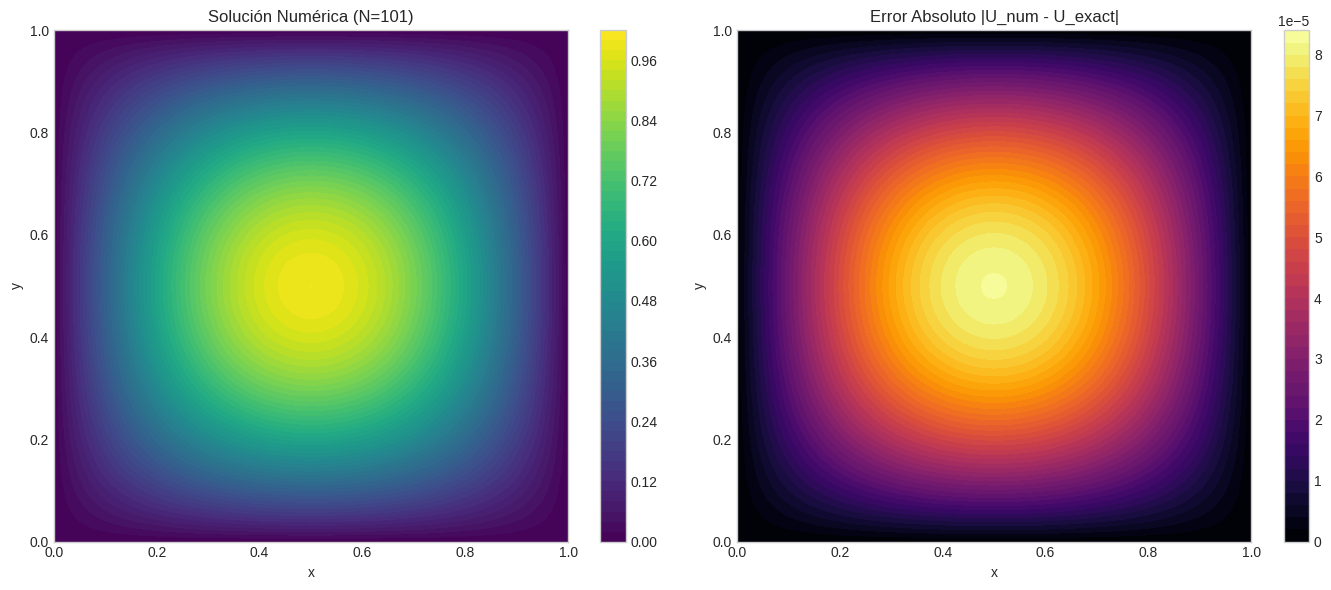

In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import time

# --- Configuración de Estilo para Gráficos ---
plt.style.use('seaborn-v0_8-whitegrid')

def exacta(X, Y):
    """Solución analítica u(x,y) = sin(pi*x)*sin(pi*y)"""
    return np.sin(np.pi * X) * np.sin(np.pi * Y)

def termino_fuente(X, Y):
    """Lado derecho de la ecuación f(x,y)"""
    return -2 * np.pi**2 * np.sin(np.pi * X) * np.sin(np.pi * Y)

def crear_laplaciano_2d(N, h):
    """
    Genera la matriz dispersa A del operador Laplaciano usando Kronecker.
    Resuelve solo para nodos internos (M x M donde M = N-2).
    """
    M = N - 2
    # Matriz 1D para segunda derivada (tridiagonal: 1, -2, 1)
    diagonals = [np.ones(M-1), -2*np.ones(M), np.ones(M-1)]
    D1 = sp.diags(diagonals, [-1, 0, 1], shape=(M, M))
    
    # Identidad
    I = sp.eye(M)
    
    # Laplaciano 2D: A = I (x) D1 + D1 (x) I
    # Dividido por h^2
    A = (sp.kron(I, D1) + sp.kron(D1, I)) / h**2
    return A.tocsr()

def solver_sor(u_guess, f, h, omega=1.5, tol=1e-5, max_iter=5000):
    """
    Solver iterativo SOR (Successive Over-Relaxation).
    Utiliza operaciones vectorizadas tipo 'Red-Black' para eficiencia en Python.
    """
    u = u_guess.copy()
    N = u.shape[0]
    err = float('inf')
    iters = 0
    
    # Coeficiente central del esquema de 5 puntos
    inv_cntr = 1.0 / 4.0 
    h2 = h**2
    
    t0 = time.time()
    
    # Máscaras tipo tablero de ajedrez (Red-Black) para vectorización
    # Esto permite actualizar la mitad de la grilla simultáneamente
    X_idx, Y_idx = np.meshgrid(np.arange(1, N-1), np.arange(1, N-1))
    mask_red = (X_idx + Y_idx) % 2 == 0
    mask_black = (X_idx + Y_idx) % 2 != 0
    
    while err > tol and iters < max_iter:
        u_old = u.copy()
        
        # Actualización Red (Pares)
        # u_new = 0.25 * (u_arriba + u_abajo + u_izq + u_der - h^2*f)
        # SOR: u = (1-w)*u_old + w*u_new
        
        # Simplificación para legibilidad del paso Gauss-Seidel:
        def update_step(mask):
            # Vecinos
            u_vecinos = (u[0:-2, 1:-1] + u[2:, 1:-1] + 
                         u[1:-1, 0:-2] + u[1:-1, 2:])
            
            # Paso Gauss-Seidel puro
            u_gs = inv_cntr * (u_vecinos - h2 * f[1:-1, 1:-1])
            
            # Aplicación de relajación (SOR) solo en la máscara actual
            u[1:-1, 1:-1][mask] = (1 - omega) * u[1:-1, 1:-1][mask] + omega * u_gs[mask]

        update_step(mask_red)   # Actualizar celdas rojas
        update_step(mask_black) # Actualizar celdas negras con la info nueva de rojas
        
        # Calcular norma infinito del cambio para convergencia
        err = np.max(np.abs(u - u_old))
        iters += 1
        
    tf = time.time()
    return u, tf - t0, iters

def ejecutar_analisis():
    resoluciones = [51, 101] # Nodos por lado
    
    print(f"{'N':<5} | {'Solver':<10} | {'RMS Error':<12} | {'L_inf Error':<12} | {'Tiempo (s)':<10} | {'Iters':<5}")
    print("-" * 70)
    
    resultados_plots = []

    for N in resoluciones:
        # 1. Configuración del Dominio
        x = np.linspace(0, 1, N)
        y = np.linspace(0, 1, N)
        X, Y = np.meshgrid(x, y)
        h = 1.0 / (N - 1)
        
        # Solución Exacta y Lado derecho (f)
        U_exact = exacta(X, Y)
        F = termino_fuente(X, Y)
        
        # --- SOLVER DIRECTO ---
        t_start = time.time()
        
        # Construir sistema lineal para nodos INTERNOS
        A = crear_laplaciano_2d(N, h)
        
        # Aplanar lado derecho (solo nodos internos)
        # F[1:-1, 1:-1] selecciona el interior, flatten() lo hace vector 1D
        b = F[1:-1, 1:-1].flatten()
        
        # Resolver Au = b
        u_int = spla.spsolve(A, b)
        
        # Reconstruir matriz completa con fronteras (que son 0)
        U_direct = np.zeros((N, N))
        U_direct[1:-1, 1:-1] = u_int.reshape((N-2, N-2))
        
        t_direct = time.time() - t_start
        
        # Métricas Directo
        diff_dir = U_direct - U_exact
        rms_dir = np.sqrt(np.mean(diff_dir**2))
        linf_dir = np.max(np.abs(diff_dir))
        
        print(f"{N:<5} | {'Directo':<10} | {rms_dir:.2e}     | {linf_dir:.2e}     | {t_direct:.4f}     | {'-'}")

        # --- SOLVER ITERATIVO (SOR) ---
        # Semilla inicial (ceros)
        U_init = np.zeros((N, N))
        omega = 1.8 # Factor de relajación óptimo suele estar cerca de 2 para N grandes
        
        U_sor, t_sor, iters = solver_sor(U_init, F, h, omega=omega, tol=1e-6)
        
        # Métricas SOR
        diff_sor = U_sor - U_exact
        rms_sor = np.sqrt(np.mean(diff_sor**2))
        linf_sor = np.max(np.abs(diff_sor))
        
        print(f"{N:<5} | {'SOR':<10} | {rms_sor:.2e}     | {linf_sor:.2e}     | {t_sor:.4f}     | {iters}")
        print("-" * 70)
        
        # Guardar para graficar el último caso
        resultados_plots = (X, Y, U_direct, diff_dir)

    # Graficar resultados del último N procesado
    X, Y, U_calc, Error = resultados_plots
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot Solución Calculada
    c1 = ax[0].contourf(X, Y, U_calc, 50, cmap='viridis')
    plt.colorbar(c1, ax=ax[0])
    ax[0].set_title(f'Solución Numérica (N={len(X)})')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('y')
    
    # Plot Error Absoluto
    c2 = ax[1].contourf(X, Y, np.abs(Error), 50, cmap='inferno')
    plt.colorbar(c2, ax=ax[1])
    ax[1].set_title(f'Error Absoluto |U_num - U_exact|')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    ejecutar_analisis()

---
# *PINN (Physics-Informed Neural Network)*
---

<>:240: SyntaxWarning: invalid escape sequence '\D'
<>:240: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipython-input-992964232.py:240: SyntaxWarning: invalid escape sequence '\D'
  ax[2].set_title('Residuo de PDE $|\Delta u - f|$')


Iniciando entrenamiento PINN...


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1340: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  current = float(metrics)


Adam Epoch 0: Loss = 9.825295e+01
Adam Epoch 500: Loss = 1.068645e-02
Adam Epoch 1000: Loss = 1.578300e-03
Adam Epoch 1500: Loss = 7.998128e-04
Adam Epoch 2000: Loss = 4.483565e-04
Adam Epoch 2500: Loss = 3.155022e-04
Adam Epoch 3000: Loss = 2.538853e-04
Adam Epoch 3500: Loss = 2.126035e-04
Adam Epoch 4000: Loss = 1.724279e-04
Adam Epoch 4500: Loss = 1.467965e-04
Fin Fase Adam. Loss: 1.295025e-03
Iniciando afinamiento LBFGS...
Fin Fase LBFGS. Final Loss = 4.298374e-06
Tiempo Total de Entrenamiento: 448.59 s
--------------------------------------------------
Métricas Finales (N=101x101):
RMS Error      : 3.6719e-06
L_inf Error    : 9.5956e-06
Max Residuo PDE: 1.3803e-02
--------------------------------------------------


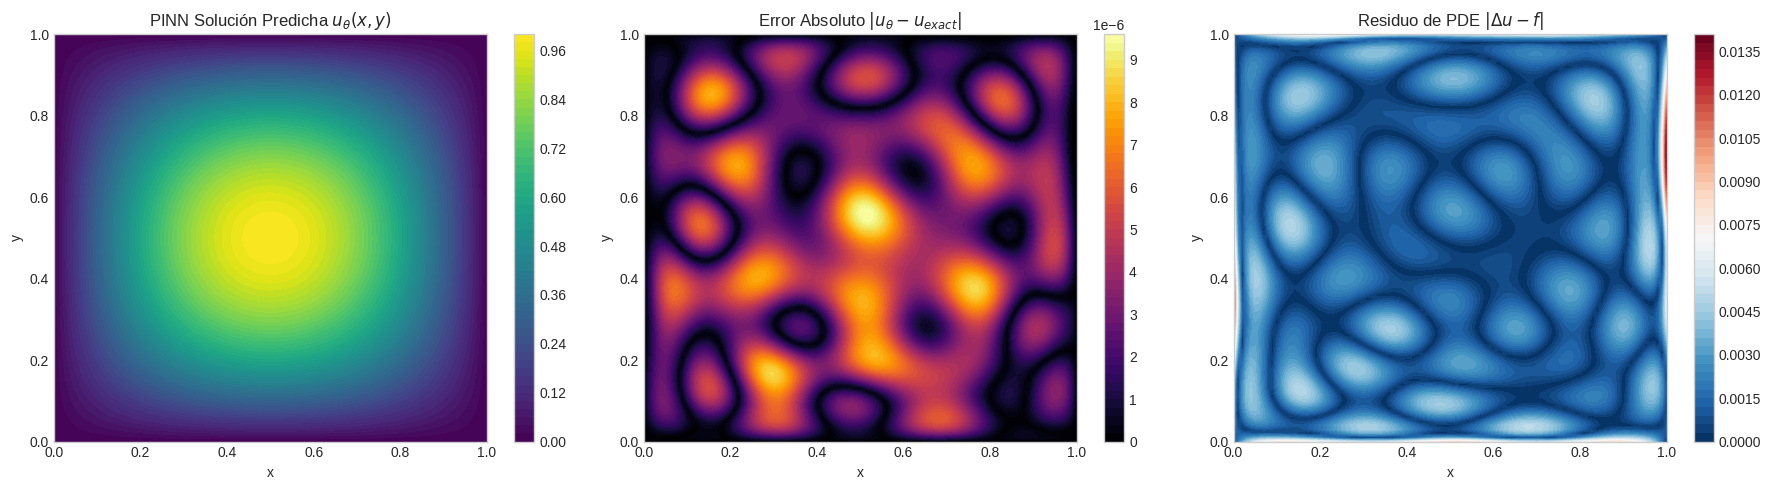

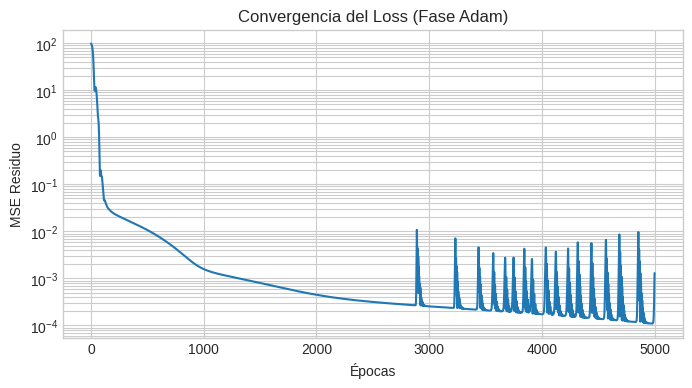

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import time

# Configuración de Semilla y Dispositivo
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Usar float64 (Double) es CRÍTICO para segundas derivadas precisas en PINNs
torch.set_default_dtype(torch.float64)

# ==========================================
# 1. Definición de la Arquitectura PINN
# ==========================================
class PoissonPINN(nn.Module):
    def __init__(self):
        super(PoissonPINN, self).__init__()
        
        # Arquitectura sugerida: [2, 128, 128, 128, 1]
        self.layers = nn.Sequential(
            nn.Linear(2, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        
        # Inicialización de Xavier (Glorot)
        self.apply(self.init_weights)

    def init_weights(self, m):
        if isinstance(m, nn.Linear):
            torch.nn.init.xavier_uniform_(m.weight)
            m.bias.data.fill_(0.0)

    def forward(self, x_in):
        # x_in shape: [Batch, 2] -> (x, y) en dominio [0, 1]
        
        # 1. Normalización de entradas a [-1, 1]
        # Como el dominio es [0, 1], la transformación es: 2*x - 1
        x_norm = 2.0 * x_in - 1.0
        
        # 2. Salida de la Red Neuronal N(x,y)
        N_output = self.layers(x_norm)
        
        # 3. Imposición Dura de BC (Hard Constraints)
        # u_trial = x(1-x)y(1-y) * N(x,y)
        # Esto fuerza que u=0 en x=0, x=1, y=0, y=1 automáticamente.
        x = x_in[:, 0:1]
        y = x_in[:, 1:2]
        distance_func = x * (1.0 - x) * y * (1.0 - y)
        
        u_pred = distance_func * N_output
        return u_pred

# ==========================================
# 2. Definición de la Física (PDE)
# ==========================================
def physics_loss(model, x_collocation):
    # Habilitar gradientes para la entrada
    x_collocation.requires_grad_(True)
    
    # Predicción u
    u = model(x_collocation)
    
    # Primera derivada (gradiente)
    # create_graph=True es necesario para poder derivar de nuevo (segunda derivada)
    grads = torch.autograd.grad(u, x_collocation, 
                                grad_outputs=torch.ones_like(u), 
                                create_graph=True)[0]
    u_x = grads[:, 0:1]
    u_y = grads[:, 1:2]
    
    # Segunda derivada
    # Gradiente de u_x respecto a x -> u_xx
    grads_x = torch.autograd.grad(u_x, x_collocation, 
                                  grad_outputs=torch.ones_like(u_x), 
                                  create_graph=True)[0]
    u_xx = grads_x[:, 0:1]
    
    # Gradiente de u_y respecto a y -> u_yy
    grads_y = torch.autograd.grad(u_y, x_collocation, 
                                  grad_outputs=torch.ones_like(u_y), 
                                  create_graph=True)[0]
    u_yy = grads_y[:, 1:2]
    
    # Laplaciano
    laplacian = u_xx + u_yy
    
    # Término Fuente (Source Term) f(x,y)
    x = x_collocation[:, 0:1]
    y = x_collocation[:, 1:2]
    f = -2 * (np.pi**2) * torch.sin(np.pi * x) * torch.sin(np.pi * y)
    
    # Residuo de la PDE: r = Δu - f
    residual = laplacian - f
    
    # Loss = MSE del residuo
    loss_f = torch.mean(residual**2)
    
    # Nota: No hay Loss_BC porque se cumple por diseño (Hard Constraint)
    return loss_f

# ==========================================
# 3. Preparación de Datos
# ==========================================
N_colloc = 10000  # Puntos de colocación
# Generación aleatoria uniforme en [0, 1] x [0, 1]
X_colloc = torch.rand((N_colloc, 2), device=device, dtype=torch.float64)

model = PoissonPINN().to(device)

# ==========================================
# 4. Bucle de Entrenamiento
# ==========================================
print("Iniciando entrenamiento PINN...")
start_time = time.time()

# --- FASE 1: Adam ---
optimizer_adam = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer_adam, patience=500, factor=0.5)

epochs_adam = 5000
loss_history = []

for epoch in range(epochs_adam):
    optimizer_adam.zero_grad()
    loss = physics_loss(model, X_colloc)
    loss.backward()
    optimizer_adam.step()
    scheduler.step(loss)
    
    loss_history.append(loss.item())
    
    if epoch % 500 == 0:
        print(f"Adam Epoch {epoch}: Loss = {loss.item():.6e}")

print(f"Fin Fase Adam. Loss: {loss.item():.6e}")

# --- FASE 2: LBFGS (Afinamiento) ---
# LBFGS requiere una función 'closure' que evalúa el loss
optimizer_lbfgs = optim.LBFGS(model.parameters(), 
                              max_iter=1000, 
                              line_search_fn="strong_wolfe", 
                              tolerance_grad=1e-9, 
                              tolerance_change=1e-9)

def closure():
    optimizer_lbfgs.zero_grad()
    loss = physics_loss(model, X_colloc)
    loss.backward()
    return loss

print("Iniciando afinamiento LBFGS...")
optimizer_lbfgs.step(closure)
final_loss = closure().item()
print(f"Fin Fase LBFGS. Final Loss = {final_loss:.6e}")

training_time = time.time() - start_time
print(f"Tiempo Total de Entrenamiento: {training_time:.2f} s")

# ==========================================
# 5. Evaluación y Métricas
# ==========================================
# Crear malla 101x101 para comparación (Igual que FD)
N_eval = 101
x_eval = torch.linspace(0, 1, N_eval)
y_eval = torch.linspace(0, 1, N_eval)
X_mesh, Y_mesh = torch.meshgrid(x_eval, y_eval, indexing='xy')

# Aplanar para pasar por la red
X_flat = X_mesh.reshape(-1, 1)
Y_flat = Y_mesh.reshape(-1, 1)
XY_eval = torch.cat([X_flat, Y_flat], dim=1).to(device)

# Predicción
model.eval()
with torch.no_grad():
    u_pred_flat = model(XY_eval)
    u_pred = u_pred_flat.reshape(N_eval, N_eval).cpu().numpy()

# Solución Exacta
X_np = X_mesh.numpy()
Y_np = Y_mesh.numpy()
u_exact = np.sin(np.pi * X_np) * np.sin(np.pi * Y_np)

# Cálculo de Errores
error_abs = np.abs(u_pred - u_exact)
error_rms = np.sqrt(np.mean(error_abs**2))
error_linf = np.max(error_abs)

# Recalcular residuo físico en la malla de evaluación (para visualización)
# Se requiere autograd, así que lo hacemos con tensores
XY_eval.requires_grad_(True)
# Reutilizamos la lógica de derivadas pero sin optimizar
u_eval_t = model(XY_eval)
g_eval = torch.autograd.grad(u_eval_t, XY_eval, torch.ones_like(u_eval_t), create_graph=True)[0]
u_x_e = g_eval[:, 0:1]
u_y_e = g_eval[:, 1:2]
u_xx_e = torch.autograd.grad(u_x_e, XY_eval, torch.ones_like(u_x_e), create_graph=True)[0][:, 0:1]
u_yy_e = torch.autograd.grad(u_y_e, XY_eval, torch.ones_like(u_y_e), create_graph=True)[0][:, 1:2]
f_eval = -2 * (np.pi**2) * torch.sin(np.pi * XY_eval[:,0:1]) * torch.sin(np.pi * XY_eval[:,1:2])
res_eval = (u_xx_e + u_yy_e - f_eval).detach().cpu().numpy().reshape(N_eval, N_eval)

print("-" * 50)
print(f"Métricas Finales (N={N_eval}x{N_eval}):")
print(f"RMS Error      : {error_rms:.4e}")
print(f"L_inf Error    : {error_linf:.4e}")
print(f"Max Residuo PDE: {np.max(np.abs(res_eval)):.4e}")
print("-" * 50)

# ==========================================
# 6. Visualización
# ==========================================
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Mapa de la solución predicha
c1 = ax[0].contourf(X_np, Y_np, u_pred, 50, cmap='viridis')
plt.colorbar(c1, ax=ax[0])
ax[0].set_title('PINN Solución Predicha $u_{\\theta}(x,y)$')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')

# Mapa del Error Absoluto
c2 = ax[1].contourf(X_np, Y_np, error_abs, 50, cmap='inferno')
plt.colorbar(c2, ax=ax[1])
ax[1].set_title('Error Absoluto $|u_{\\theta} - u_{exact}|$')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')

# Mapa del Residuo de la PDE
c3 = ax[2].contourf(X_np, Y_np, np.abs(res_eval), 50, cmap='RdBu_r')
plt.colorbar(c3, ax=ax[2])
ax[2].set_title('Residuo de PDE $|\Delta u - f|$')
ax[2].set_xlabel('x')
ax[2].set_ylabel('y')

plt.tight_layout()
plt.show()

# Gráfica de Historial de Pérdida (Adam)
plt.figure(figsize=(8, 4))
plt.semilogy(loss_history)
plt.title('Convergencia del Loss (Fase Adam)')
plt.xlabel('Épocas')
plt.ylabel('MSE Residuo')
plt.grid(True, which="both", ls="-")
plt.show()